# MDS Lab 3 Program 1

# Name : SAMIM ALI
# Roll No. : 24MDS031
# Student ID : 202404435

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Create a single feature single target dataset using sin(x) + e, where e is Gaussian Noise with zero mean and small variance

In [4]:
x = np.linspace(-2*np.pi, 2*np.pi, 200)
y = np.sin(x).ravel() + np.random.normal(0, 0.1, 200)

In [5]:
df = pd.DataFrame(data = {"X" : x, "y" : y})

In [6]:
df

,X,y
0,-6.283185,0.033317
1,-6.220038,0.005879
2,-6.156890,0.214234
3,-6.093743,0.441366
4,-6.030595,0.342017
...,...,...
195,6.030595,-0.109624
196,6.093743,-0.255351
197,6.156890,-0.208427
198,6.220038,-0.020501


In [7]:
X, y = df[["X"]], df[["y"]]

# 1) Use matplotlib to perform data analysis on the dataset and plot scatter of feature vs target

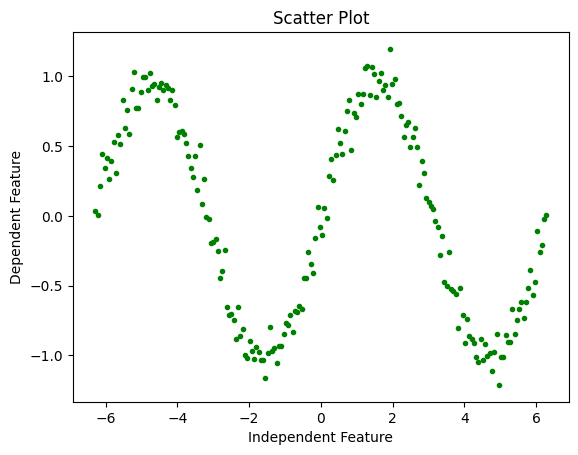

In [8]:
plt.scatter(x = X, y = y, color = "green", marker = ".")
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot")
plt.show()

# 2) Normalize the dataset

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

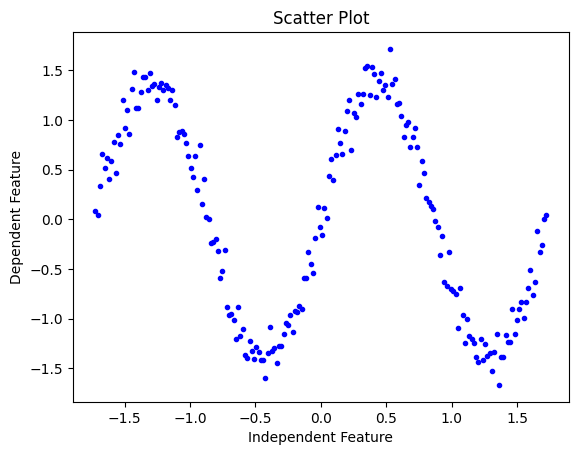

In [10]:
plt.scatter(x = X, y = y, color = "blue", marker = ".")
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot")
plt.show()

# 3) Develop the loss function according to the generic polynomial loss function

# Train Test Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

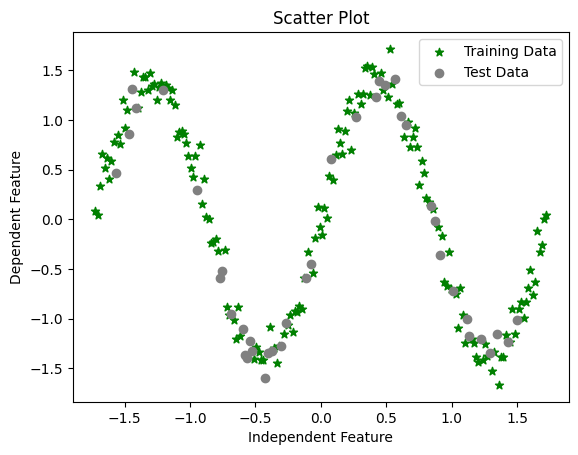

In [12]:
plt.scatter(x = X_train, y = y_train, color = "green", marker = "*", label = "Training Data")
plt.scatter(x = X_test, y = y_test, color = "grey", marker = "o", label = "Test Data")
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.legend()
plt.title("Scatter Plot")
plt.show()

In [13]:
def polynomial_features(X, degree):
  return np.hstack([X ** power for power in range(degree + 1)])

In [14]:
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [15]:
def gradient_descent(X, y, degree, learning_rate=0.01, epochs=1000):
    X_poly = polynomial_features(X, degree)
    m, n = X_poly.shape
    theta = np.zeros((n, 1))  # Ensure theta is a column vector
    y = y.reshape(-1, 1)  # Ensure y is a column vector
    
    for _ in range(epochs):
        y_pred = X_poly @ theta  # Prediction shape (m, 1)
        gradient = (-2/m) * (X_poly.T @ (y - y_pred))  # Shape (n, 1)
        theta -= learning_rate * gradient
    
    return theta.flatten()  # Convert back to 1D array


# 5) Calculate the coefficients

In [16]:
# Train models for M = 0 to 9
train_errors, test_errors, coefficients = [], [], []

for M in range(10):
    theta = gradient_descent(X_train, y_train, M)
    coefficients.append(theta)
    
    y_train_pred = polynomial_features(X_train, M) @ theta
    y_test_pred = polynomial_features(X_test, M) @ theta
    
    train_errors.append(compute_loss(y_train, y_train_pred))
    test_errors.append(compute_loss(y_test, y_test_pred))

# 6) Display the list of coefficients against each model of degree M = 0 to 9

In [17]:
# Step 6: Display coefficients
for M, coeff in enumerate(coefficients):
    print(f"Degree {M}: Coefficients: {coeff}")

Degree 0: Coefficients: [0.06788907]
Degree 1: Coefficients: [ 0.06487235 -0.40980785]
Degree 2: Coefficients: [ 0.10289703 -0.40993086 -0.03621981]
Degree 3: Coefficients: [ 0.09187227  0.21787554 -0.02489667 -0.33935149]
Degree 4: Coefficients: [ 0.08838267  0.21829844 -0.01832353 -0.33953455 -0.0019353 ]
Degree 5: Coefficients: [ 0.0815826   0.76099879 -0.04331985 -1.56412494  0.00794151  0.41621138]
Degree 6: Coefficients: [ 0.08779084  0.76001689 -0.01178533 -1.56449738 -0.05128008  0.41651908
  0.01798641]
Degree 7: Coefficients: [nan nan nan nan nan nan nan nan]
Degree 8: Coefficients: [nan nan nan nan nan nan nan nan nan]
Degree 9: Coefficients: [nan nan nan nan nan nan nan nan nan nan]


# 7) Plot the train and test error for each model of degree M = 0 to 9

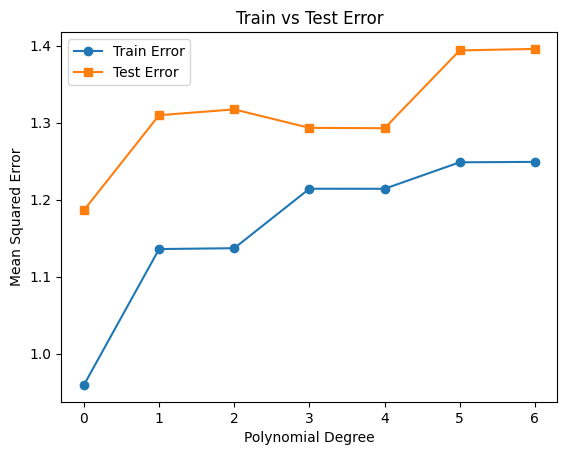

In [18]:
# Step 7: Plot train and test errors
plt.plot(range(10), train_errors, label='Train Error', marker='o')
plt.plot(range(10), test_errors, label='Test Error', marker='s')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test Error")
plt.legend()
plt.show()
